# BANCO DE DADOS 2

## escolha:
-   mercado: will paris saint-germain win the uefa champions league?
-   pergunta: como o volume de apostas se comportou conforme o PSG avancou na champions league? 
-   hipotese: a expectativa e' que o volume negociado aumente conforme o PSG avanca na competicao, principalmente nas fases finais  

In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

plt.style.use("ggplot") 

# compreensao inicial do mercado

antes de analisar os dados diarios, conferi se o mercado escolhido era o correto e quais eram suas informacoes gerais

In [2]:
-- query sql (executar no big query)

SELECT
    market_id,
    question,
    event_title,
    created_at,
    end_date,
    volume,
    closed

FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE market_id = '507305';

SyntaxError: invalid syntax (1352295966.py, line 1)

In [4]:
df_mercado = pd.read_csv('dados/informacoes_mercado.csv')

df_mercado

,market_id,question,event_title,created_at,end_date,volume,closed
0,507305,Will Paris Saint-Germain win the UEFA Champion...,Champions League Winner,2024-09-17 17:30:16.000000 UTC,2025-05-31 12:00:00.000000 UTC,5.132058e+07,1


o resultado confirmou que o mercado escolhido corresponde ao caminho do PSG para o titulo da champions league de 2025,
tambem foi possivel verificar o periodo em que o mercado ficou aberto e o volume total negociado durante esse intervalo

# exploracao da serie diaria
    
depois disso passei para os dados agregados por dia, eles vao servir de base para montar as metricas e os alertas mais a frente

In [ ]:
-- query sql (executar no big query)

SELECT
    trade_date,
    daily_trade_count,
    daily_usd_volume,
    avg_trade_price,
    min_trade_price,
    max_trade_price
    
FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
WHERE market_id = '507305'
ORDER BY trade_date;

SyntaxError: invalid syntax (2567310518.py, line 1)

In [5]:
df_serie_diaria = pd.read_csv('dados/serie_diaria.csv')

df_serie_diaria

,trade_date,daily_trade_count,daily_usd_volume,avg_trade_price,min_trade_price,max_trade_price
0,2024-09-17,8,82.86,0.146250,0.030,0.940
1,2024-09-18,39,114.57,0.133077,0.030,0.960
2,2024-09-19,36,67.42,0.057611,0.030,0.963
3,2024-09-20,33,35.30,0.033121,0.032,0.038
4,2024-09-21,17,36.22,0.197176,0.031,0.968
...,...,...,...,...,...,...
252,2025-05-27,1106,108500.42,0.557769,0.402,0.599
253,2025-05-28,135,16631.11,0.504459,0.406,0.593
254,2025-05-29,676,21214.09,0.472087,0.406,0.593
255,2025-05-30,642,87562.39,0.464835,0.402,0.598


In [13]:
print(df_serie_diaria.info(),'\n')
print(df_serie_diaria.head(),'\n')


<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   trade_date         257 non-null    str    
 1   daily_trade_count  257 non-null    int64  
 2   daily_usd_volume   257 non-null    float64
 3   avg_trade_price    257 non-null    float64
 4   min_trade_price    257 non-null    float64
 5   max_trade_price    257 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 12.2 KB
None 

   trade_date  daily_trade_count  daily_usd_volume  avg_trade_price  \
0  2024-09-17                  8             82.86         0.146250   
1  2024-09-18                 39            114.57         0.133077   
2  2024-09-19                 36             67.42         0.057611   
3  2024-09-20                 33             35.30         0.033121   
4  2024-09-21                 17             36.22         0.197176   

   min_trade_price  max_trade_

In [7]:
print(df_serie_diaria.describe())

df_serie_diaria.isna().sum()

       daily_trade_count  daily_usd_volume  avg_trade_price  min_trade_price  \
count         257.000000      2.570000e+02       257.000000       257.000000   
mean          678.696498      1.232521e+05         0.258696         0.113016   
std          2393.805651      6.088521e+05         0.207315         0.134999   
min             1.000000      1.700000e-01         0.017301         0.001000   
25%            77.000000      8.111000e+02         0.055364         0.019000   
50%           166.000000      2.471590e+03         0.226311         0.035000   
75%           528.000000      1.918343e+04         0.457185         0.213000   
max         26879.000000      5.134644e+06         0.912538         0.419000   

       max_trade_price  
count       257.000000  
mean          0.768459  
std           0.307966  
min           0.018000  
25%           0.728000  
50%           0.940000  
75%           0.980000  
max           0.999000  


trade_date           0
daily_trade_count    0
daily_usd_volume     0
avg_trade_price      0
min_trade_price      0
max_trade_price      0
dtype: int64

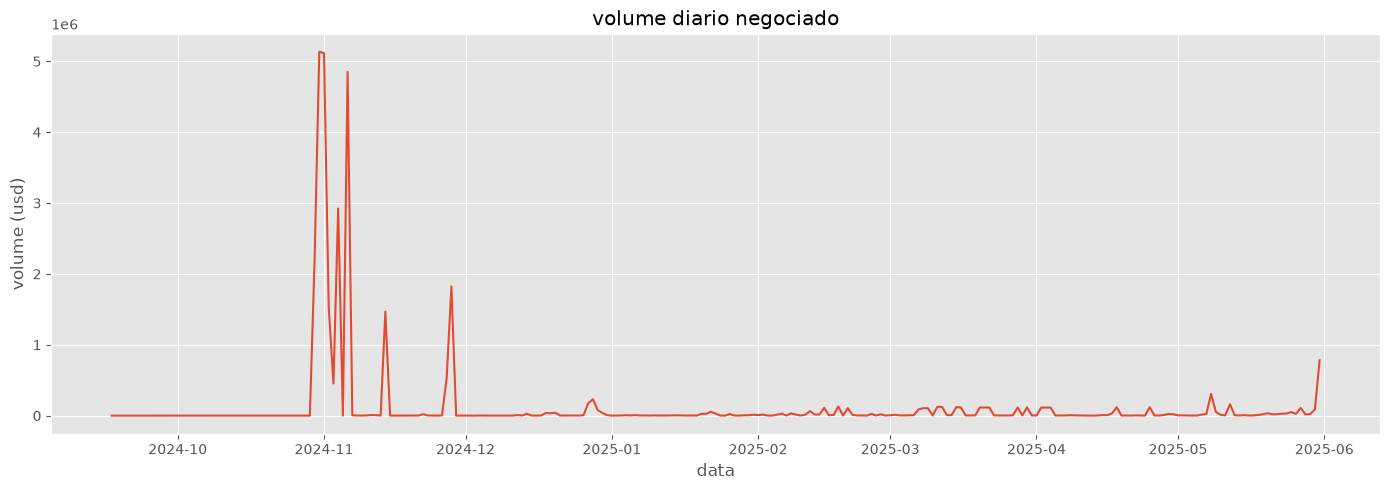

In [10]:
plt.figure(figsize=(14,5))

plt.plot(
    pd.to_datetime(df_serie_diaria["trade_date"]),
    df_serie_diaria["daily_usd_volume"],
    linewidth=1.5
)

plt.title("volume diario negociado")
plt.xlabel("data")
plt.ylabel("volume (usd)")

plt.tight_layout()
plt.show()

o volume negociado permaneceu relativamente baixo durante boa parte do periodo, mas apresentou alguns picos bem acima da media,
esses picos indicam momentos em que houve um aumento significativo no interesse pelo mercado

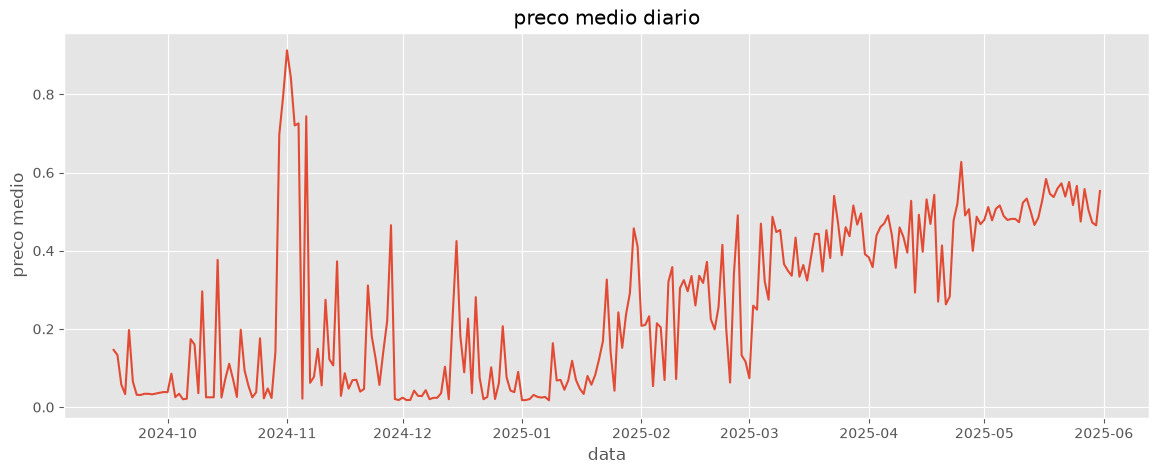

In [11]:
plt.figure(figsize=(14,5))

plt.plot(
    pd.to_datetime(df_serie_diaria["trade_date"]),
    df_serie_diaria["avg_trade_price"]
)

plt.title("preco medio diario")
plt.xlabel("data")
plt.ylabel("preco medio") 

plt.show()

o preco medio variou bastante no inicio do mercado e ficou mais estavel conforme a competicao avancou,
isso mostra que a expectativa do mercado foi sendo ajustada ao longo do campeonato

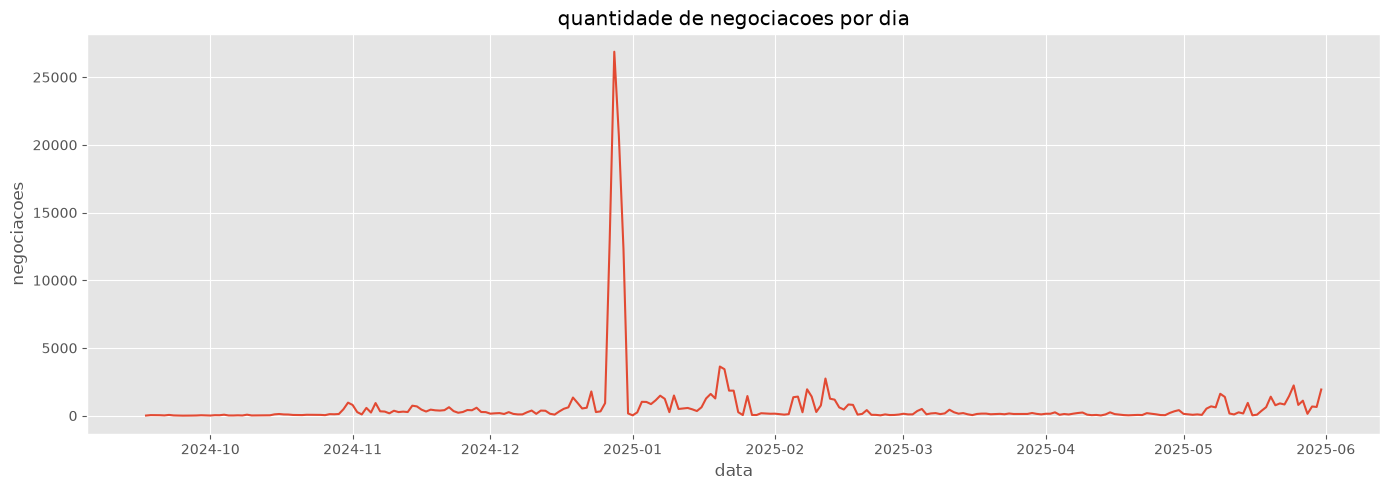

In [12]:
plt.figure(figsize=(14,5))

plt.plot(
    pd.to_datetime(df_serie_diaria["trade_date"]),
    df_serie_diaria["daily_trade_count"]
)

plt.title("quantidade de negociacoes por dia")
plt.xlabel("data")
plt.ylabel("negociacoes")

plt.tight_layout()
plt.show()

a quantidade de negociacoes tambem apresentou picos em datas especificas,
isso sugere que o aumento do volume nao aconteceu apenas por operacoes maiores mas tambem por um aumento na atividade dos usuarios 

nessa consulta ja e possivel observar que existem alguns dias com volumes muito acima do restante da serie,
isso motivou a criacao do primeiro alerta, baseado em picos de volume 

## metricas calculadas

alem da serie diaria, calculei algumas metricas para acompanhar melhor a evolucao do mercado.
Essas metricas permitem comparar o volume de um dia com os dias anteriores e servem de base para os alertas definidos na atividade

In [ ]:
-- query sql (executar no big query)
-- gera as metricas da serie inteira: volume/preco do dia anterior e media movel de 7 dias

WITH base AS (
    SELECT
        trade_date,
        daily_trade_count,
        daily_usd_volume,
        avg_trade_price
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
    WHERE market_id = '507305'
),

metricas AS (
    SELECT
        trade_date,
        daily_trade_count,
        daily_usd_volume,
        avg_trade_price,

        LAG(daily_usd_volume) OVER (
            ORDER BY trade_date
        ) AS volume_dia_anterior,

        LAG(avg_trade_price) OVER (
            ORDER BY trade_date
        ) AS preco_dia_anterior,

        AVG(daily_usd_volume) OVER (
            ORDER BY trade_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS media_volume_7d

    FROM base
)

SELECT *
FROM metricas
ORDER BY trade_date;

essa consulta gera a media movel de 7 dias pra cada dia da serie, que depois vira a base do alerta de volume

In [15]:
df_metricas = pd.read_csv('dados/metricas.csv')

df_metricas

,trade_date,daily_trade_count,daily_usd_volume,avg_trade_price,volume_dia_anterior,preco_dia_anterior,media_volume_7d
0,2024-09-17,8,82.86,0.146250,NaN,NaN,82.860000
1,2024-09-18,39,114.57,0.133077,82.86,0.146250,98.715000
2,2024-09-19,36,67.42,0.057611,114.57,0.133077,88.283333
3,2024-09-20,33,35.30,0.033121,67.42,0.057611,75.037500
4,2024-09-21,17,36.22,0.197176,35.30,0.033121,67.274000
...,...,...,...,...,...,...,...
252,2025-05-27,1106,108500.42,0.557769,26037.68,0.474584,39936.444286
253,2025-05-28,135,16631.11,0.504459,108500.42,0.557769,39713.540000
254,2025-05-29,676,21214.09,0.472087,16631.11,0.504459,39827.888571
255,2025-05-30,642,87562.39,0.464835,21214.09,0.472087,48538.787143


In [17]:
print(df_metricas.info(),'\n')
print(df_metricas.head(),'\n')


<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trade_date           257 non-null    str    
 1   daily_trade_count    257 non-null    int64  
 2   daily_usd_volume     257 non-null    float64
 3   avg_trade_price      257 non-null    float64
 4   volume_dia_anterior  256 non-null    float64
 5   preco_dia_anterior   256 non-null    float64
 6   media_volume_7d      257 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 14.2 KB
None 

   trade_date  daily_trade_count  daily_usd_volume  avg_trade_price  \
0  2024-09-17                  8             82.86         0.146250   
1  2024-09-18                 39            114.57         0.133077   
2  2024-09-19                 36             67.42         0.057611   
3  2024-09-20                 33             35.30         0.033121   
4  2024-09-21                 17    

In [18]:
print(df_metricas.describe())

df_metricas.isna().sum()

       daily_trade_count  daily_usd_volume  avg_trade_price  \
count         257.000000      2.570000e+02       257.000000   
mean          678.696498      1.232521e+05         0.258696   
std          2393.805651      6.088521e+05         0.207315   
min             1.000000      1.700000e-01         0.017301   
25%            77.000000      8.111000e+02         0.055364   
50%           166.000000      2.471590e+03         0.226311   
75%           528.000000      1.918343e+04         0.457185   
max         26879.000000      5.134644e+06         0.912538   

       volume_dia_anterior  preco_dia_anterior  media_volume_7d  
count         2.560000e+02          256.000000     2.570000e+02  
mean          1.206789e+05            0.257547     1.201916e+05  
std           6.086429e+05            0.206900     3.985426e+05  
min           1.700000e-01            0.017301     2.431000e+01  
25%           8.068675e+02            0.055173     2.581003e+03  
50%           2.467470e+03          

trade_date             0
daily_trade_count      0
daily_usd_volume       0
avg_trade_price        0
volume_dia_anterior    1
preco_dia_anterior     1
media_volume_7d        0
dtype: int64

In [ ]:
# trata os dados nulos, substituindo por 0 (os nulos que sao relacionados ao dia anterior, onde nao ha dia anterior)

df_metricas = df_metricas.fillna(0)

df_metricas.isna().sum()

trade_date             0
daily_trade_count      0
daily_usd_volume       0
avg_trade_price        0
volume_dia_anterior    0
preco_dia_anterior     0
media_volume_7d        0
dtype: int64

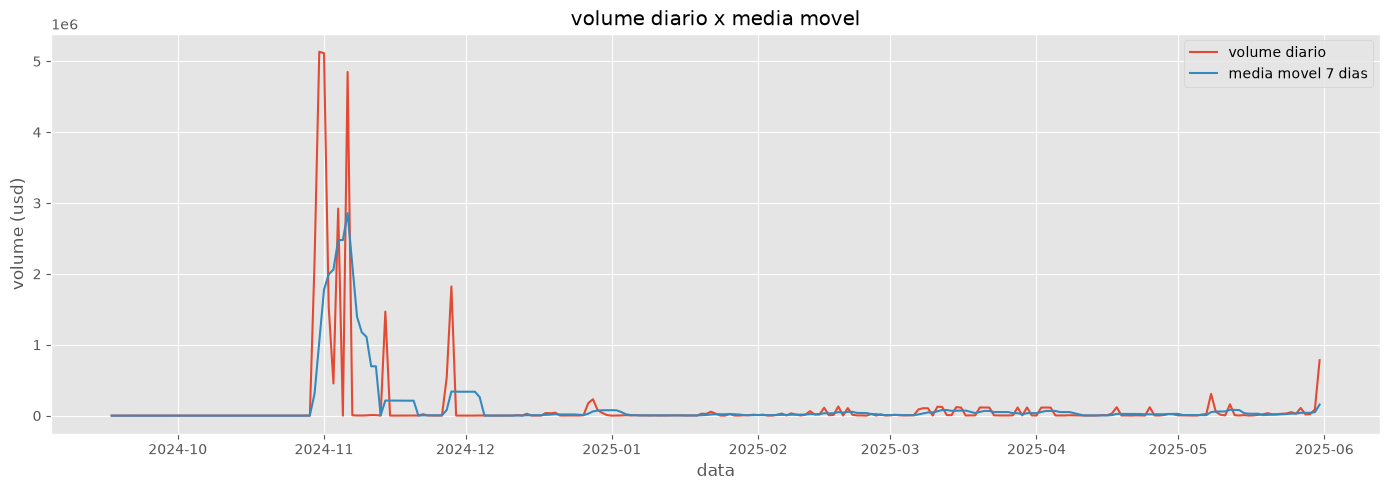

In [21]:
plt.figure(figsize=(14,5))

plt.plot(
    pd.to_datetime(df_metricas["trade_date"]),
    df_metricas["daily_usd_volume"],
    label="volume diario"
)

plt.plot(
    pd.to_datetime(df_metricas["trade_date"]),
    df_metricas["media_volume_7d"],
    label="media movel 7 dias"
)

plt.title("volume diario x media movel")

plt.xlabel("data")
plt.ylabel("volume (usd)")

plt.legend()

plt.tight_layout()

plt.show()

a media movel ajuda a reduzir a variacao diaria e facilita identificar momentos em que o volume ficou muito acima do comportamento normal

nos picos observados, o volume diario supera bastante a media dos dias anteriores

## alerta de volume

In [ ]:
-- alerta de volume, query sql (executar no big query)
WITH base AS (
    SELECT
    
        trade_date,
        daily_trade_count,
        daily_usd_volume,
        avg_trade_price
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
    WHERE market_id = '507305'
),


metricas AS (
    SELECT

        trade_date,
        daily_trade_count,
        daily_usd_volume,
        avg_trade_price,

        AVG(daily_usd_volume) OVER (
            ORDER BY trade_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS media_volume_7d

    FROM base
)


SELECT
    trade_date,
    daily_trade_count,
    daily_usd_volume,
    media_volume_7d,
    ROUND(daily_usd_volume / media_volume_7d, 2) AS razao_volume
FROM metricas
WHERE
    media_volume_7d > 0
    AND daily_usd_volume >= 2 * media_volume_7d
ORDER BY trade_date;

In [22]:
df_alerta_volume = pd.read_csv('dados/alerta_volume.csv')

df_alerta_volume

,trade_date,daily_trade_count,daily_usd_volume,media_volume_7d,razao_volume
0,2024-09-29,30,86.29,2.431000e+01,3.55
1,2024-09-30,18,59.50,2.832143e+01,2.10
2,2024-10-07,25,173.95,6.986714e+01,2.49
3,2024-10-16,121,378.12,1.265886e+02,2.99
4,2024-10-17,89,1234.20,2.920900e+02,4.23
5,2024-10-20,44,975.84,4.480971e+02,2.18
6,2024-10-21,42,1498.74,6.388086e+02,2.35
7,2024-10-29,121,594.07,2.780271e+02,2.14
8,2024-10-30,473,2187287.60,3.127256e+05,6.99
9,2024-10-31,961,5134643.85,1.046187e+06,4.91


In [23]:
print(df_alerta_volume.info(),'\n')
print(df_alerta_volume.head(),'\n')


<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   trade_date         52 non-null     str    
 1   daily_trade_count  52 non-null     int64  
 2   daily_usd_volume   52 non-null     float64
 3   media_volume_7d    52 non-null     float64
 4   razao_volume       52 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 2.2 KB
None 

   trade_date  daily_trade_count  daily_usd_volume  media_volume_7d  \
0  2024-09-29                 30             86.29        24.310000   
1  2024-09-30                 18             59.50        28.321429   
2  2024-10-07                 25            173.95        69.867143   
3  2024-10-16                121            378.12       126.588571   
4  2024-10-17                 89           1234.20       292.090000   

   razao_volume  
0          3.55  
1          2.10  
2          2.49  
3        

In [24]:
print(df_alerta_volume.describe())

df_alerta_volume.isna().sum()

       daily_trade_count  daily_usd_volume  media_volume_7d  razao_volume
count          52.000000      5.200000e+01     5.200000e+01     52.000000
mean         1417.788462      3.807381e+05     9.144692e+04      3.606346
std          4067.255877      1.052602e+06     2.848089e+05      1.481940
min            18.000000      5.950000e+01     2.431000e+01      2.020000
25%           114.000000      1.803403e+04     5.765549e+03      2.337500
50%           455.500000      3.942144e+04     1.536913e+04      3.140000
75%           946.000000      1.185245e+05     4.625827e+04      4.912500
max         26879.000000      5.134644e+06     1.776794e+06      6.990000


trade_date           0
daily_trade_count    0
daily_usd_volume     0
media_volume_7d      0
razao_volume         0
dtype: int64

In [33]:
# transforma os valores de data de string para datetime

df_alerta_volume["trade_date"] = pd.to_datetime(df_alerta_volume["trade_date"])
print(df_alerta_volume.info(),'\n')

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   trade_date         52 non-null     datetime64[us]
 1   daily_trade_count  52 non-null     int64         
 2   daily_usd_volume   52 non-null     float64       
 3   media_volume_7d    52 non-null     float64       
 4   razao_volume       52 non-null     float64       
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 2.2 KB
None 



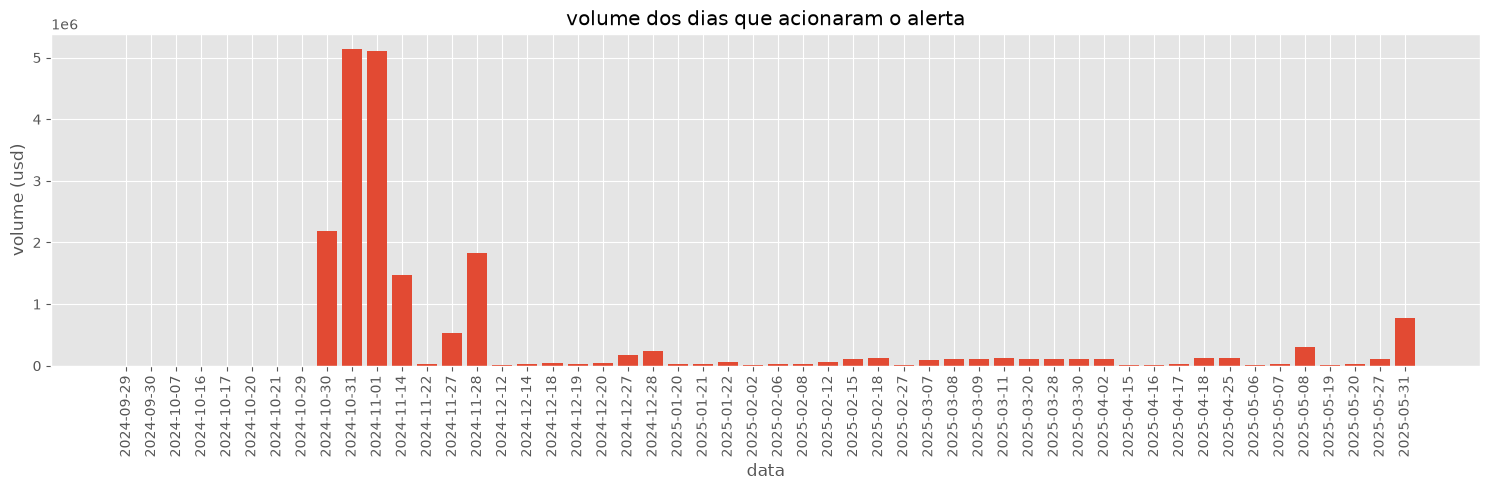

In [ ]:
plt.figure(figsize=(15,5))

plt.bar(
    df_alerta_volume["trade_date"].dt.strftime("%Y-%m-%d"),
    df_alerta_volume["daily_usd_volume"]
)


plt.xticks(rotation=90) 

plt.title("volume dos dias que acionaram o alerta")
plt.xlabel("data")
plt.ylabel("volume (usd)")


plt.tight_layout()
plt.show()

os primeiros alertas ocorreram com volumes relativamente baixos porque o mercado ainda estava no inicio, fazendo com que a media movel tambem fosse baixa

## alerta de preco

In [ ]:
-- alerta de preço, query sql (executar no big query)
WITH base AS (
    SELECT

        trade_date,
        avg_trade_price
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
    WHERE market_id = '507305'
),

metricas AS (
    SELECT

        trade_date,
        avg_trade_price,

        LAG(avg_trade_price) OVER (
            ORDER BY trade_date
        ) AS preco_dia_anterior

    FROM base
)

SELECT

    trade_date,
    preco_dia_anterior,
    avg_trade_price,

    ROUND(
        avg_trade_price - preco_dia_anterior,
        4
    ) AS variacao_preco

FROM metricas

WHERE
    preco_dia_anterior IS NOT NULL
    AND ABS(avg_trade_price - preco_dia_anterior) >= 0.10

ORDER BY trade_date;


o segundo alerta verifica dias em que o preco medio variou de forma significativa em relacao ao dia anterior,
isso ajuda a identificar momentos em que a percepcao do mercado mudou rapidamente

In [27]:
df_alerta_preco = pd.read_csv('dados/alerta_preco.csv')

df_alerta_preco

,trade_date,preco_dia_anterior,avg_trade_price,variacao_preco
0,2024-09-21,0.033121,0.197176,0.1641
1,2024-09-22,0.197176,0.065444,-0.1317
2,2024-10-07,0.021538,0.173800,0.1523
3,2024-10-09,0.160000,0.035507,-0.1245
4,2024-10-10,0.035507,0.296214,0.2607
...,...,...,...,...
70,2025-04-21,0.413455,0.262556,-0.1509
71,2025-04-23,0.282600,0.476766,0.1942
72,2025-04-25,0.520357,0.627172,0.1068
73,2025-04-26,0.627172,0.490182,-0.1370


In [28]:
print(df_alerta_preco.info(),'\n')
print(df_alerta_preco.head(),'\n')


<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   trade_date          75 non-null     str    
 1   preco_dia_anterior  75 non-null     float64
 2   avg_trade_price     75 non-null     float64
 3   variacao_preco      75 non-null     float64
dtypes: float64(3), str(1)
memory usage: 2.5 KB
None 

   trade_date  preco_dia_anterior  avg_trade_price  variacao_preco
0  2024-09-21            0.033121         0.197176          0.1641
1  2024-09-22            0.197176         0.065444         -0.1317
2  2024-10-07            0.021538         0.173800          0.1523
3  2024-10-09            0.160000         0.035507         -0.1245
4  2024-10-10            0.035507         0.296214          0.2607 



In [29]:
print(df_alerta_preco.describe())

df_alerta_preco.isna().sum()

       preco_dia_anterior  avg_trade_price  variacao_preco
count           75.000000        75.000000       75.000000
mean             0.273931         0.285769        0.011837
std              0.201658         0.197450        0.251270
min              0.017301         0.020711       -0.704200
25%              0.072822         0.136044       -0.151500
50%              0.269731         0.262556        0.117600
75%              0.396125         0.419874        0.189250
max              0.843050         0.912538        0.722400


trade_date            0
preco_dia_anterior    0
avg_trade_price       0
variacao_preco        0
dtype: int64

In [32]:
# transforma os valores de data de string para datetime

df_alerta_preco["trade_date"] = pd.to_datetime(df_alerta_preco["trade_date"])

print(df_alerta_preco.info(),'\n')



<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   trade_date          75 non-null     datetime64[us]
 1   preco_dia_anterior  75 non-null     float64       
 2   avg_trade_price     75 non-null     float64       
 3   variacao_preco      75 non-null     float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 2.5 KB
None 



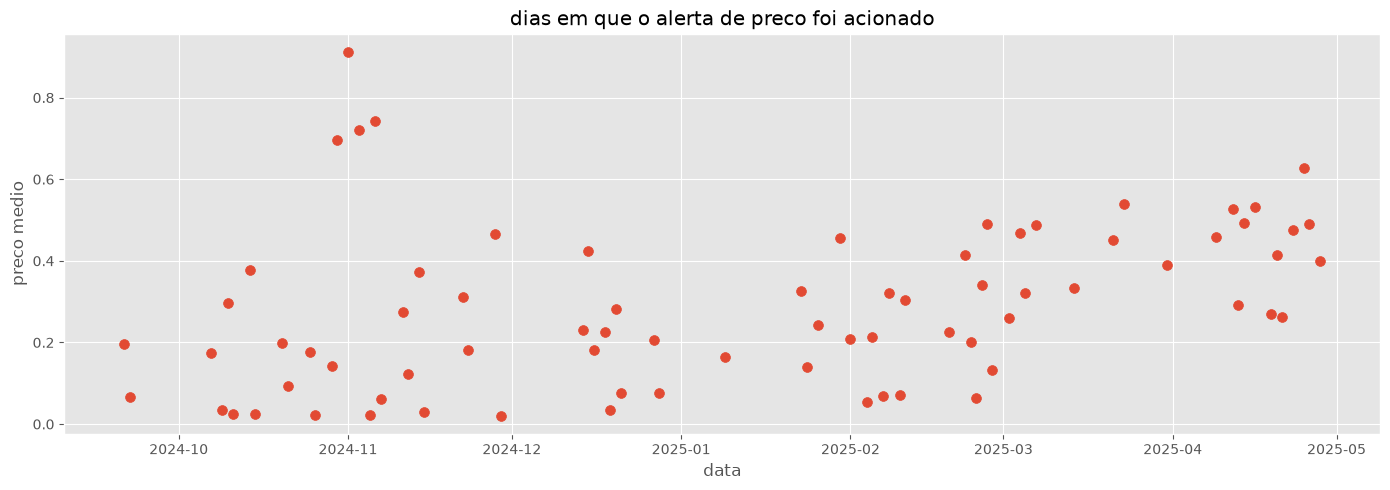

In [34]:
plt.figure(figsize=(14,5))

plt.scatter(
    df_alerta_preco["trade_date"],
    df_alerta_preco["avg_trade_price"],
    s=50
)

plt.title("dias em que o alerta de preco foi acionado")

plt.xlabel("data")
plt.ylabel("preco medio")

plt.tight_layout()

plt.show()

os alertas de preco aconteceram em momentos especificos da competicao,
isso indica mudancas mais bruscas na expectativa dos apostadores em relacao as chances do PSG conquistar o titulo.

## Metrica de assertividade

pra medir a assertividade, comparei as datas que os alertas dispararam com as datas reais das fases eliminatorias do psg (oitavas, quartas, semi e final). isso mostra se o alerta ta pegando movimento real de jogo ou so ruido do mercado

In [ ]:
# datas reais das fases eliminatorias do psg na champions 2024-2025
datas_chave = pd.to_datetime([
    "2025-03-05", "2025-03-12",  # oitavas
    "2025-04-09", "2025-04-16",  # quartas
    "2025-04-30", "2025-05-07",  # semi
    "2025-05-31",                # final
])

def calcula_assertividade(df_alerta, janela_dias=1):
    acertos = df_alerta["trade_date"].apply(
        lambda d: any(abs((d - dc).days) <= janela_dias for dc in datas_chave)
    )
    return acertos.sum(), len(df_alerta), acertos.mean()

acertos_volume, total_volume, taxa_volume = calcula_assertividade(df_alerta_volume)
acertos_preco, total_preco, taxa_preco = calcula_assertividade(df_alerta_preco)

print(f"alerta de volume: {acertos_volume}/{total_volume} disparos perto de jogo decisivo ({taxa_volume:.1%})")
print(f"alerta de preco: {acertos_preco}/{total_preco} disparos perto de jogo decisivo ({taxa_preco:.1%})")

alerta de volume: 8/52 disparos perto de jogo decisivo (15.4%)
alerta de preco: 4/75 disparos perto de jogo decisivo (5.3%)


o alerta de volume acertou mais que o esperado por acaso (15.4% vs ~8.2%), entao ele parece pegar reacao real aos jogos. o alerta de preco fez o oposto, ficou abaixo do acaso (5.3%), entao ele deve estar captando mais ruido do mercado do que reacao a jogo mesmo

## limitacoes

- o inicio do periodo (setembro a dezembro de 2024) teve pouca liquidez, com poucas negociacoes por dia e o preco variando muito (de 0.02 a 0.9 em poucos dias), entao os sinais desse trecho sao mais ruido do que informacao real
- o alerta de preco teve assertividade abaixo da linha de base aleatoria (5.3% vs ~8.2% esperado por acaso), o que sugere que ele capta mais ruido geral de mercado do que reacao especifica a jogos decisivos
- a janela de +-1 dia usada na assertividade e uma escolha simples, jogos podem ter efeito no mercado antes ou depois desse intervalo, ou o mercado pode reagir a noticias que nao estao nas datas de jogo (lesao, escalacao, transferencia)
- essa analise nao prova causalidade, so mostra que os alertas coincidem (ou nao) temporalmente com jogos decisivos

## conclusao

a analise do mercado do psg na champions mostrou bastante variacao de volume e preco ao longo do periodo, principalmente perto das fases eliminatorias. o alerta de volume confirma parte da hipotese, ja que ele acerta mais que o acaso quando tem jogo decisivo. o alerta de preco nao confirma tanto assim, ele parece pegar mais ruido geral do que reacao especifica a jogo.

no fim, a hipotese se confirma em parte: o mercado realmente reage mais perto de jogo importante, mas nem todo alerta capta isso do mesmo jeito